# Import

In [28]:
import numpy as np
import pandas as pd

# File system manangement
import os

# Visualisation : matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Réglage affichage des datasets
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 125)

# Functions

In [30]:
def check_dataframe_health(df):
    """
    Analyse un DataFrame pour identifier les doublons, les valeurs manquantes 
    et les types de données par colonne.
    
    Args:
        df (pd.DataFrame): Le jeu de données à analyser.
        
    Returns:
        pd.DataFrame: Un résumé statistique de la santé du dataset.
    """
    
    # 1. Calcul du nombre total de doublons dans le dataset  
    total_duplicates = df.duplicated().sum()

    # 2. Analyse par colonne (Valeurs manquantes, Proportion, Types)
    
    # Nombre de valeurs manquantes
    missing_count = df.isnull().sum()
    
    # Proportion de valeurs manquantes (en %)
    missing_percent = (df.isnull().sum() / len(df)) * 100

    print("--------------------- Analyse Globale ---------------------")
    print(f"Nombre total de lignes en double : {total_duplicates}")
    print(f"Nombre total d'observations : {df.shape[0]}")
    print(f"Nombre total de variables : {df.shape[1]}")
    print(f"Nombre de colonnes avec des valeurs manquantes : {(missing_count > 0).sum()} ({(missing_count > 0).sum()/df.shape[1] * 100:.2f}%)")
    print("-" * 59)

    # Types de données
    data_types = df.dtypes
    
    # Création d'un DataFrame de synthèse
    health_report = pd.DataFrame({
        'Type de donnée': data_types,
        'Valeurs manquantes': missing_count,
        'Proportion (%)': missing_percent.round(2)
    })
    
    # Tri par le nombre de valeurs manquantes pour voir les plus critiques en haut
    return health_report.sort_values(by='Valeurs manquantes', ascending=False)


In [31]:
def get_feature_descriptions(columns_to_find, HomeCredit_columns_description):
    """
    Récupère les descriptions pour une liste spécifique de colonnes.
    
    Args:
        columns_to_find (list): Liste des noms de colonnes à chercher.
        HomeCredit_columns_description (pd.DataFrame): Le dataset HomeCredit_columns_description.
        
    Returns:
        pd.DataFrame: Un tableau avec le nom de la colonne et sa description.
    """
    # On filtre les lignes où la colonne 'Row' correspond à nos variables
    # Note : Dans ce dataset, les noms de colonnes sont dans 'Row'
    filtered_desc = HomeCredit_columns_description[HomeCredit_columns_description['Row'].isin(columns_to_find)]
    
    return filtered_desc[['Row', 'Description']].reset_index(drop=True)

In [32]:
def analyze_categorical_features(df, column_list):
    """
    Analyse une liste de colonnes catégorielles pour afficher 
    les occurrences et le taux de valeurs manquantes.
    
    Args:
        df (pd.DataFrame): Le dataset à analyser.
        column_list (list): Liste des noms de colonnes catégorielles.
        
    Returns:
        dict: Un dictionnaire contenant les DataFrames de résumé pour chaque colonne.
    """
    all_summaries = {}
    
    for col in column_list:
        if col not in df.columns:
            print(f"Erreur : La colonne '{col}' est introuvable dans le dataset.")
            continue
            
        # 1. Calcul des valeurs manquantes
        missing_val = df[col].isnull().sum()
        missing_prop = (missing_val / len(df)) * 100
        
        print(f"\n{'='*40}")
        print(f"ANALYSE DE LA VARIABLE : {col}")
        print(f"{'='*40}")
        print(f"Taux de valeurs manquantes : {missing_val} ({missing_prop:.2f}%)")
        print("-" * 40)
        
        # 2. Calcul des occurrences et proportions
        counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(dropna=False, normalize=True) * 100
        
        summary = pd.DataFrame({
            'Occurrences': counts,
            'Proportion (%)': percentages.round(2)
        })
        
        print(summary)
        all_summaries[col] = summary
        
    return

# Data Load & EDA

Ce projet comporte 10 datasets que nous allons chargés et analysés.

## LOAD

### HomeCredit_columns_description.csv

Ce jeu de données fait office de dictionnaire pour l'ensemble du projet. Il se compose de **5 colonnes** et de **219 lignes**, où chaque ligne détaille une variable présente dans les différents fichiers sources.

Il apporte une aide précieuse à la compréhension du métier grâce à :

* **L'identification des variables :** Une correspondance directe entre les noms de colonnes et leur signification concrète.

* **La colonne "Special" :** Celle-ci est particulièrement stratégique car elle répertorie les traitements spécifiques appliqués aux données (ex: normalisation, regroupements de catégories ou transformations temporelles).

**Impact sur le projet :**
L'exploitation de ce dictionnaire est indispensable pour guider **l'EDA** et orienter le **Feature Engineering**, en permettant de cibler les variables les plus pertinentes pour prédire le risque de défaut de paiement.

In [33]:
HomeCredit_columns_description = pd.read_csv(
    "../datas/HomeCredit_columns_description.csv",
    encoding="ISO-8859-1"
)

HomeCredit_columns_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   219 non-null    int64
 1   Table        219 non-null    str  
 2   Row          219 non-null    str  
 3   Description  219 non-null    str  
 4   Special      86 non-null     str  
dtypes: int64(1), str(4)
memory usage: 43.2 KB


In [34]:
HomeCredit_columns_description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [35]:
HomeCredit_columns_description["Special"].value_counts()

Special
normalized                               53
time only relative to the application    19
hashed                                    9
rounded                                   2
normalized                                1
recoded                                   1
grouped                                   1
Name: count, dtype: int64

### application_train.csv

In [36]:
app_train = pd.read_csv(
    "../datas/application_train.csv",
    encoding="ISO-8859-1"
    )

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [37]:
check_dataframe_health(app_train)

--------------------- Analyse Globale ---------------------
Nombre total de lignes en double : 0
Nombre total d'observations : 307511
Nombre total de variables : 122
Nombre de colonnes avec des valeurs manquantes : 67 (54.92%)
-----------------------------------------------------------


,Type de donnée,Valeurs manquantes,Proportion (%)
COMMONAREA_AVG,float64,214865,69.87
COMMONAREA_MODE,float64,214865,69.87
COMMONAREA_MEDI,float64,214865,69.87
NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43
NONLIVINGAPARTMENTS_MODE,float64,213514,69.43
NONLIVINGAPARTMENTS_AVG,float64,213514,69.43
FONDKAPREMONT_MODE,str,210295,68.39
LIVINGAPARTMENTS_AVG,float64,210199,68.35
LIVINGAPARTMENTS_MEDI,float64,210199,68.35
LIVINGAPARTMENTS_MODE,float64,210199,68.35


In [38]:
app_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [39]:
numerical_cols = app_train.select_dtypes(include=[np.number]).columns
categorical_cols = app_train.select_dtypes(include=['object']).columns

print(f"Nombre de variables numériques : {len(numerical_cols)}")
print(f"Nombre de variables catégorielles : {len(categorical_cols)}")

Nombre de variables numériques : 106
Nombre de variables catégorielles : 16


/tmp/ipykernel_38322/958188525.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = app_train.select_dtypes(include=['object']).columns


In [40]:
app_train[categorical_cols].nunique().sort_values(ascending=False).head(50)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

In [41]:
get_feature_descriptions(categorical_cols, HomeCredit_columns_description)

,Row,Description
0,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
1,CODE_GENDER,Gender of the client
2,FLAG_OWN_CAR,Flag if the client owns a car
3,FLAG_OWN_REALTY,Flag if client owns a house or flat
4,NAME_TYPE_SUITE,Who was accompanying client when he was applyi...
5,NAME_INCOME_TYPE,"Clients income type (businessman, working, mat..."
6,NAME_EDUCATION_TYPE,Level of highest education the client achieved
7,NAME_FAMILY_STATUS,Family status of the client
8,NAME_HOUSING_TYPE,What is the housing situation of the client (r...
9,OCCUPATION_TYPE,What kind of occupation does the client have


In [42]:
analyze_categorical_features(app_train, categorical_cols)


ANALYSE DE LA VARIABLE : NAME_CONTRACT_TYPE
Taux de valeurs manquantes : 0 (0.00%)
----------------------------------------
                    Occurrences  Proportion (%)
NAME_CONTRACT_TYPE                             
Cash loans               278232           90.48
Revolving loans           29279            9.52

ANALYSE DE LA VARIABLE : CODE_GENDER
Taux de valeurs manquantes : 0 (0.00%)
----------------------------------------
             Occurrences  Proportion (%)
CODE_GENDER                             
F                 202448           65.83
M                 105059           34.16
XNA                    4            0.00

ANALYSE DE LA VARIABLE : FLAG_OWN_CAR
Taux de valeurs manquantes : 0 (0.00%)
----------------------------------------
              Occurrences  Proportion (%)
FLAG_OWN_CAR                             
N                  202924           65.99
Y                  104587           34.01

ANALYSE DE LA VARIABLE : FLAG_OWN_REALTY
Taux de valeurs manquantes : 0 

In [43]:
app_train[numerical_cols].head(10)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,1.0,2,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,0.0149,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,2.0,1,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,0.0714,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,1.0,2,2,9,0,0,0,0,0,0,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,2.0,2,2,17,0,0,0,0,0,0,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,1,0,0,1.0,2,2,11,0,0,0,0,1,1,NaN,0.322738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [44]:
duplicat_SK_ID_CURR = app_train["SK_ID_CURR"].duplicated().sum()
print(f"Nombre de doublons dans SK_ID_CURR : {duplicat_SK_ID_CURR}")

duplica_app_train = app_train.duplicated().sum()
print(f"Nombre de lignes dans le DataFrame des doublons : {duplica_app_train}")


Nombre de doublons dans SK_ID_CURR : 0
Nombre de lignes dans le DataFrame des doublons : 0


In [45]:
HomeCredit_columns_description[HomeCredit_columns_description["Row"] == "OWN_CAR_AGE"]["Description"].values[0]

"Age of client's car"

In [46]:
app_train["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

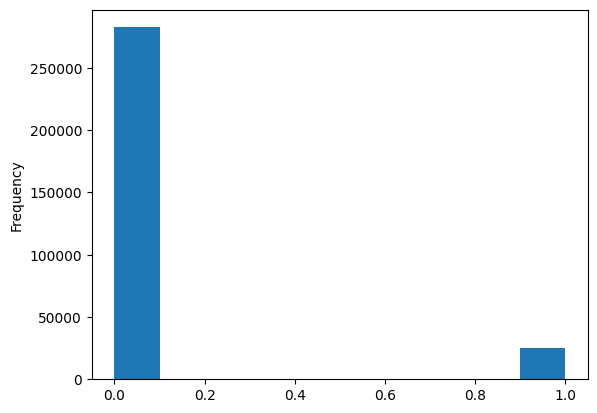

In [47]:
app_train['TARGET'].astype(int).plot.hist()

In [48]:
num_cols = [col for col in numerical_cols if col not in ["SK_ID_CURR", "TARGET"]]  # Exclure SK_ID_CURR et TARGET des statistiques numériques

In [49]:
len(num_cols)

104

In [50]:
app_train[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.42,0.72,0.00,0.00,0.00,1.00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.00,112500.00,147150.00,202500.00,1.170000e+08
AMT_CREDIT,307511.0,599026.00,402490.78,45000.00,270000.00,513531.00,808650.00,4.050000e+06
AMT_ANNUITY,307499.0,27108.57,14493.74,1615.50,16524.00,24903.00,34596.00,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.21,369446.46,40500.00,238500.00,450000.00,679500.00,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.02,0.01,0.00,0.01,0.02,0.03,7.000000e-02
DAYS_BIRTH,307511.0,-16037.00,4363.99,-25229.00,-19682.00,-15750.00,-12413.00,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.05,141275.77,-17912.00,-2760.00,-1213.00,-289.00,3.652430e+05
DAYS_REGISTRATION,307511.0,-4986.12,3522.89,-24672.00,-7479.50,-4504.00,-2010.00,0.000000e+00
DAYS_ID_PUBLISH,307511.0,-2994.20,1509.45,-7197.00,-4299.00,-3254.00,-1720.00,0.000000e+00


Text(0.5, 0, 'Days Employment')

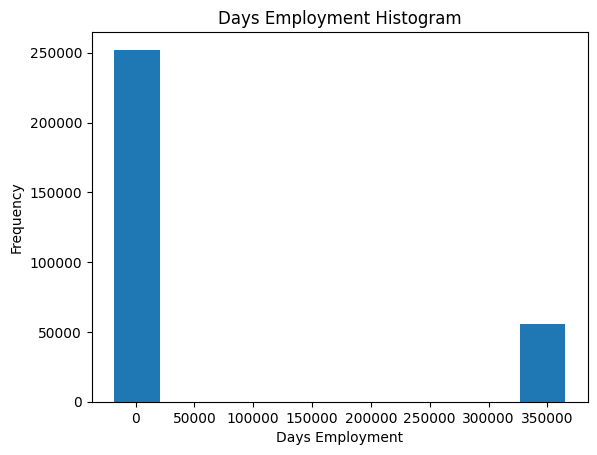

In [51]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

In [52]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]            # 18 250 jours = 50 ans, ce qui est une durée d'emploi très longue et peu réaliste
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('Les défauts de paiement non anormaux concernent %0.2f%% des prêts' % (100 * non_anom['TARGET'].mean()))
print('Les défauts de paiement non anormaux concernent %0.2f%% des prêts' % (100 * anom['TARGET'].mean()))
print('Il y a %d jours d\'emploi anormaux' % len(anom))

Les défauts de paiement non anormaux concernent 8.66% des prêts
Les défauts de paiement non anormaux concernent 5.40% des prêts
Il y a 55374 jours d'emploi anormaux


Les principales données d'entraînement contenant des informations sur chaque demande de prêt chez Home Credit.

Chaque prêt dispose de sa propre ligne et est identifié par la caractéristique SK_ID_CURR.

Les données d'entraînement sont accompagnées de la cible indiquant 0 : le prêt a été remboursé ou 1 : le prêt n'a pas été remboursé.

Ce dataset contient :
- 106 varibales numériques : 65 float et 41 int
- 16 variables catégorielles : 16 string

67 colonnes sur 122 (54.92%) ont des valeurs manquantes.

---

L'analyse de la qualité et de la distribution des **16 variables catégorielles** permet de tirer les conclusions suivantes pour la suite du projet :

1. Varibales fiables

    * Les variables fondamentales (`CODE_GENDER`, `FLAG_OWN_CAR`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`) présentent un taux de remplissage de 100%.

    * Déséquilibres notables :

        * `NAME_CONTRACT_TYPE` : Dominance massive des "Cash loans" (90,5%).

        * `CODE_GENDER` : Majorité de femmes (65,8%). On note 4 individus "XNA" qui devront être traités comme du bruit.

        * `NAME_INCOME_TYPE` : Plus de 50% des clients sont dans la catégorie "Working".

2. Données manquantes

    Plusieurs variables présentent des taux de valeurs manquantes critiques qui impacteront la stratégie de modélisation :

    * Occupation : `OCCUPATION_TYPE` manque pour 31,35% des clients.

    * Logement & Bâtiment : Les variables normalisées (`FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE`) sont absentes pour 47% à 68% du dataset.

---

Voici les variables numériques surlequelles une analyse descriptives n'est pas nécessaires :

* `SK_ID_CURR` : est l'identifiant du dataframe, les statistiques n'ont pas de sens sur cette variable. cependant on l'utilisera pour vérifer les duplicats

---

On constate donc un déséquilibre de classe, en effet on voit moins de défaut de paiement (8,07%) que de clients qui honorrent les mensualités de prêt.

---

L'analyse des varibales numériques permet de tirer les conclusions ci-dessous :

1. Outliers :

    * `CNT_CHILDREN` : Q3 = 1, max = 19 → peu probable d'avoir 19 enfants dans un contexte de crédit

    * `AMT_INCOME_TOTAL` : Q3 = 202 500, mais max = 117 000 000 (soit environ 578 fois le Q3 !) => revenu aberrant

    * `DAYS_EMPLOYED` : Q3 = -289 jours, mais max = 365 243 jours (environ 1000 ans d'emploi) => donnée aberrante
    
        Les défauts de paiement non anormaux concernent 8.66% des prêts

        Les défauts de paiement non anormaux concernent 5.40% des prêts
        
        Il y a 55374 jours d'emploi anormaux

    * `OBS_30_CNT_SOCIAL_CIRCLE` : Q3 = 2, max = 348 => outlier évident

    * `AMT_REQ_CREDIT_BUREAU_QRT` : Q3 = 0, max = 261 => demandes de crédit anormalement élevées

2. Écart-type VS la moyenne : forte dispersion avec des valeurs extrêmes

    * `MT_INCOME_TOTAL` : mean = 168 797, std = 237 123 (std > mean)

    * `DAYS_EMPLOYED` : mean = 63 815, std = 141 275 (std > 2*mean)

    * `OWN_CAR_AGE` : mean = 12,06, std = 11,94 (std ≈ mean)

3. Moyenne VS Médiane : asymétrie causé par des outliers

    * `DAYS_EMPLOYED` : médiane = -1213, moyenne = 63 815 => forte asymétrie positive

    * `AMT_INCOME_TOTAL` : médiane = 147 150, moyenne = 168 797 => tirée vers le haut par les hauts revenus

4. A creuser

    * `OWN_CAR_AGE` : max = 91 ans => voiture de collection ou erreur ?

    * 

/tmp/ipykernel_38322/2870602562.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243
/tmp/ipykernel_38322/2870602562.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value

Text(0.5, 0, 'Days Employment')

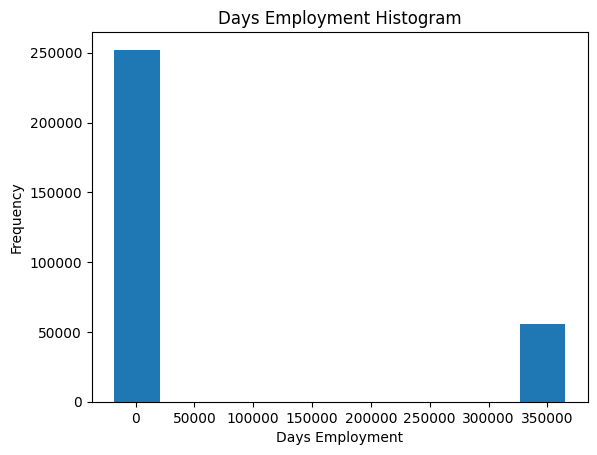

In [53]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

### application_test.csv

In [7]:
app_test = pd.read_csv(
    "../datas/application_test.csv",
    encoding="ISO-8859-1"
    )

### bureau_balance.csv

In [8]:
bureau_balance = pd.read_csv(
    "../datas/bureau_balance.csv",
    encoding="ISO-8859-1")

### bureau.csv

In [9]:
bureau = pd.read_csv(
    "../datas/bureau.csv",
    encoding="ISO-8859-1"
    )

### credit_card_balance.csv

In [10]:
credit_card_balance = pd.read_csv(
    "../datas/credit_card_balance.csv",
    encoding="ISO-8859-1"
    )

### installments_payments.csv

In [11]:
installments_payments = pd.read_csv(
    "../datas/installments_payments.csv",
    encoding="ISO-8859-1"
    )

### POS_CASH_balance.csv

In [12]:
POS_CASH_balance = pd.read_csv(
    "../datas/POS_CASH_balance.csv",
    encoding="ISO-8859-1"
    )

### previous_application.csv

In [13]:
previous_application = pd.read_csv(
    "../datas/previous_application.csv",
    encoding="ISO-8859-1"
    )

### sample_submission.csv

In [14]:
sample_submission = pd.read_csv(
    "../datas/sample_submission.csv",
    encoding="ISO-8859-1"
    )